<a href="https://colab.research.google.com/github/saltyyboii/landslide-risk-assessment/blob/main/Mountain_Hazard_Review_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Based Multi-Hazard Prediction System

## Day 1 — Landslide Dataset Exploration

In [1]:
print("Hello Mountain Hazard Project!")

Hello Mountain Hazard Project!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/content/landslide.csv")

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
df.head()

,source_name,source_link,event_id,event_date,event_time,event_title,event_description,location_description,location_accuracy,landslide_category,...,country_code,admin_division_name,admin_division_population,gazeteer_closest_point,gazeteer_distance,submitted_date,created_date,last_edited_date,longitude,latitude
0,AGU,https://blogs.agu.org/landslideblog/2008/10/14...,684,08/01/2008 12:00:00 AM,NaN,"Sigou Village, Loufan County, Shanxi Province","occurred early in morning, 11 villagers buried...","Sigou Village, Loufan County, Shanxi Province",unknown,landslide,...,CN,Shaanxi,0.0,Jingyang,41.02145,04/01/2014 12:00:00 AM,11/20/2017 03:17:00 PM,02/15/2018 03:51:00 PM,107.4500,32.5625
1,Oregonian,http://www.oregonlive.com/news/index.ssf/2009/...,956,01/02/2009 02:00:00 AM,NaN,"Lake Oswego, Oregon",Hours of heavy rain are to blame for an overni...,"Lake Oswego, Oregon",5km,mudslide,...,US,Oregon,36619.0,Lake Oswego,0.60342,04/01/2014 12:00:00 AM,11/20/2017 03:17:00 PM,02/15/2018 03:51:00 PM,-122.6630,45.4200
2,CBS News,https://www.cbsnews.com/news/dozens-missing-af...,973,01/19/2007 12:00:00 AM,NaN,"San Ramon district, 195 miles northeast of the...",(CBS/AP) At least 10 people died and as many a...,"San Ramon district, 195 miles northeast of the...",10km,landslide,...,PE,Junín,14708.0,San Ramón,0.85548,04/01/2014 12:00:00 AM,11/20/2017 03:17:00 PM,02/15/2018 03:51:00 PM,-75.3587,-11.1295
3,Reuters,https://in.reuters.com/article/idINIndia-41450...,1067,07/31/2009 12:00:00 AM,NaN,Dailekh district,"One person was killed in Dailekh district, pol...",Dailekh district,unknown,landslide,...,NP,Mid Western,20908.0,Dailekh,0.75395,04/01/2014 12:00:00 AM,11/20/2017 03:17:00 PM,02/15/2018 03:51:00 PM,81.7080,28.8378
4,The Freeman,http://www.philstar.com/cebu-news/621414/lands...,2603,10/16/2010 12:00:00 PM,NaN,sitio Bakilid in barangay Lahug,Another landslide in sitio Bakilid in barangay...,sitio Bakilid in barangay Lahug,5km,landslide,...,PH,Central Visayas,798634.0,Cebu City,2.02204,04/01/2014 12:00:00 AM,11/20/2017 03:17:00 PM,02/15/2018 03:51:00 PM,123.8978,10.3336


In [6]:
df.columns.tolist()

['source_name',
 'source_link',
 'event_id',
 'event_date',
 'event_time',
 'event_title',
 'event_description',
 'location_description',
 'location_accuracy',
 'landslide_category',
 'landslide_trigger',
 'landslide_size',
 'landslide_setting',
 'fatality_count',
 'injury_count',
 'storm_name',
 'photo_link',
 'notes',
 'event_import_source',
 'event_import_id',
 'country_name',
 'country_code',
 'admin_division_name',
 'admin_division_population',
 'gazeteer_closest_point',
 'gazeteer_distance',
 'submitted_date',
 'created_date',
 'last_edited_date',
 'longitude',
 'latitude']

In [7]:
df["landslide_trigger"].value_counts()

,count
landslide_trigger,
downpour,4680
rain,2592
unknown,1691
continuous_rain,748
tropical_cyclone,561
snowfall_snowmelt,135
monsoon,129
mining,93
earthquake,89


In [8]:
df["landslide_category"].value_counts()

,count
landslide_category,
landslide,7648
mudslide,2100
rock_fall,671
complex,232
debris_flow,194
other,68
unknown,38
riverbank_collapse,37
snow_avalanche,15


In [9]:
df["country_code"].value_counts().head(20)

,count
country_code,
US,2992
IN,1265
PH,675
NP,481
CN,426
ID,355
GB,229
BR,214
CA,174


In [10]:
nepal = df[df["country_code"] == "NP"]

print(nepal.shape)

(481, 31)


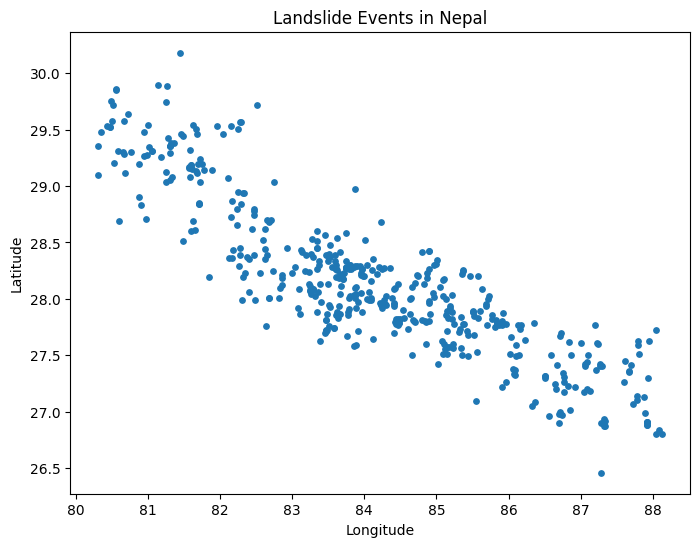

In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(
    nepal["longitude"],
    nepal["latitude"],
    s=15
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Landslide Events in Nepal")

plt.show()

In [12]:
df["landslide_trigger"].value_counts()

,count
landslide_trigger,
downpour,4680
rain,2592
unknown,1691
continuous_rain,748
tropical_cyclone,561
snowfall_snowmelt,135
monsoon,129
mining,93
earthquake,89


In [13]:
df["landslide_category"].value_counts()

,count
landslide_category,
landslide,7648
mudslide,2100
rock_fall,671
complex,232
debris_flow,194
other,68
unknown,38
riverbank_collapse,37
snow_avalanche,15


In [14]:
nepal = df[df["country_code"] == "NP"]
print(nepal.shape)

(481, 31)


In [15]:
nepal = df[df["country_code"] == "NP"].copy()

In [16]:
nepal[["event_date", "latitude", "longitude"]].head()

,event_date,latitude,longitude
3,07/31/2009 12:00:00 AM,28.8378,81.7080
39,07/02/2009 03:00:00 AM,28.2039,83.9806
40,07/02/2009 12:00:00 AM,27.9447,84.2279
46,07/27/2009 12:00:00 AM,28.0000,85.7100
47,07/31/2009 12:00:00 AM,28.1046,83.8791


In [17]:
nepal["event_date"] = pd.to_datetime(
    nepal["event_date"],
    errors="coerce"
)

/tmp/ipykernel_6163/941996008.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  nepal["event_date"] = pd.to_datetime(


In [18]:
nepal["event_date"] = pd.to_datetime(
    nepal["event_date"],
    format="%m/%d/%Y %I:%M:%S %p",
    errors="coerce"
)

In [19]:
nepal[["event_date", "latitude", "longitude"]].head()

,event_date,latitude,longitude
3,2009-07-31 00:00:00,28.8378,81.7080
39,2009-07-02 03:00:00,28.2039,83.9806
40,2009-07-02 00:00:00,27.9447,84.2279
46,2009-07-27 00:00:00,28.0000,85.7100
47,2009-07-31 00:00:00,28.1046,83.8791


In [20]:
!pip install -q earthengine-api geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 54.3 MB/s eta 0:00:00


In [21]:
import ee
import geemap

In [23]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 11033
Number of columns: 31


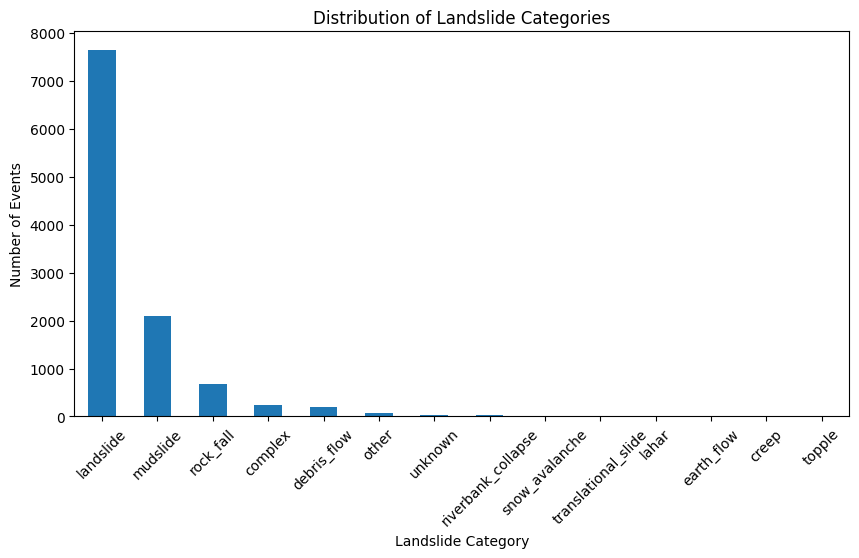

In [31]:
# EDA 1: Distribution of landslide categories

plt.figure(figsize=(10, 5))

df["landslide_category"].value_counts().plot(kind="bar")

plt.title("Distribution of Landslide Categories")
plt.xlabel("Landslide Category")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)

plt.show()

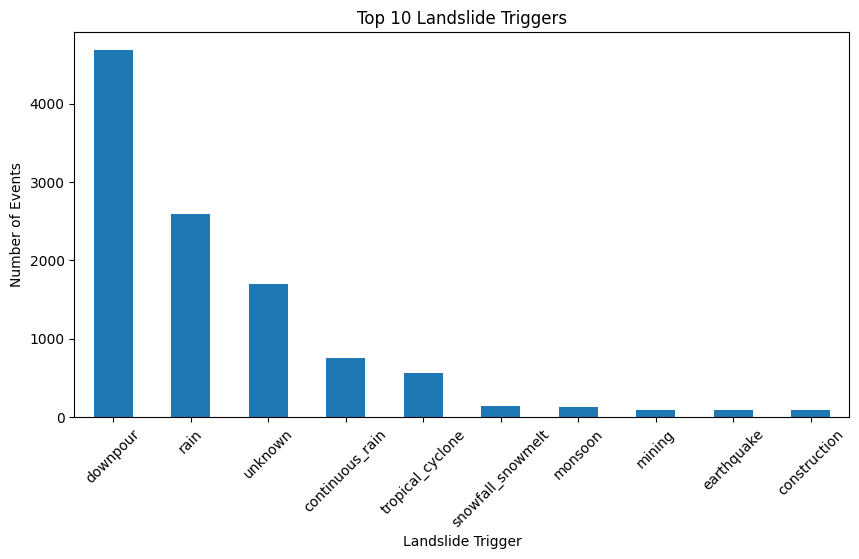

In [32]:
# EDA 2: Distribution of landslide triggers

plt.figure(figsize=(10, 5))

df["landslide_trigger"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Landslide Triggers")
plt.xlabel("Landslide Trigger")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)

plt.show()

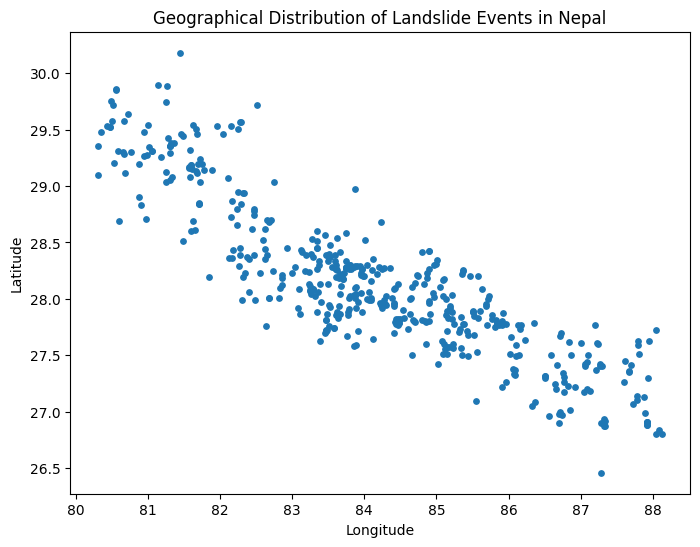

In [33]:
# EDA 3: Geographical distribution of landslides in Nepal

plt.figure(figsize=(8, 6))

plt.scatter(
    nepal["longitude"],
    nepal["latitude"],
    s=15
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Distribution of Landslide Events in Nepal")

plt.show()

In [35]:
# Convert event_date from text into datetime format
nepal["event_date"] = pd.to_datetime(
    nepal["event_date"],
    format="%m/%d/%Y %I:%M:%S %p",
    errors="coerce"
)

# Check that the conversion worked
print(nepal["event_date"].dtype)

datetime64[ns]


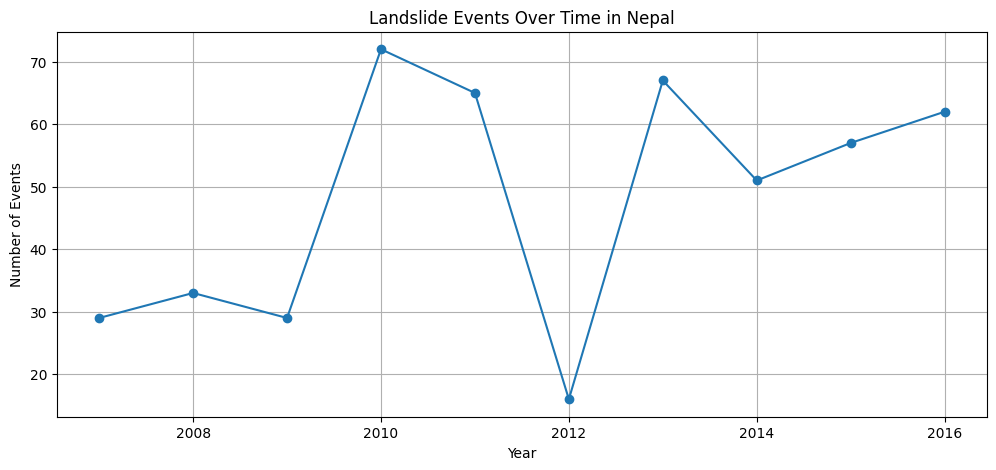

In [36]:
# EDA 4: Number of landslide events by year

# Extract the year from the event date
nepal["year"] = nepal["event_date"].dt.year

# Count landslide events for each year
yearly_events = nepal["year"].value_counts().sort_index()

# Plot the number of events over time
plt.figure(figsize=(12, 5))

plt.plot(
    yearly_events.index,
    yearly_events.values,
    marker="o"
)

plt.title("Landslide Events Over Time in Nepal")
plt.xlabel("Year")
plt.ylabel("Number of Events")

plt.grid(True)
plt.show()

In [37]:
# EDA 5: Relationship between landslide category and trigger

cross_tab = pd.crosstab(
    nepal["landslide_category"],
    nepal["landslide_trigger"]
)

display(cross_tab)

landslide_trigger,construction,continuous_rain,downpour,earthquake,flooding,mining,monsoon,rain,snowfall_snowmelt,tropical_cyclone,unknown
landslide_category,,,,,,,,,,,
complex,0,0,5,0,0,0,0,1,0,0,0
landslide,1,56,204,7,2,1,26,92,1,1,47
mudslide,0,2,11,0,0,4,0,3,1,0,1
riverbank_collapse,0,0,1,0,0,0,0,0,0,0,1
rock_fall,0,1,0,2,0,0,1,1,0,0,4
snow_avalanche,0,0,0,0,0,0,0,0,0,0,1
unknown,0,0,0,0,0,0,1,0,0,0,2


<Figure size 1200x600 with 0 Axes>

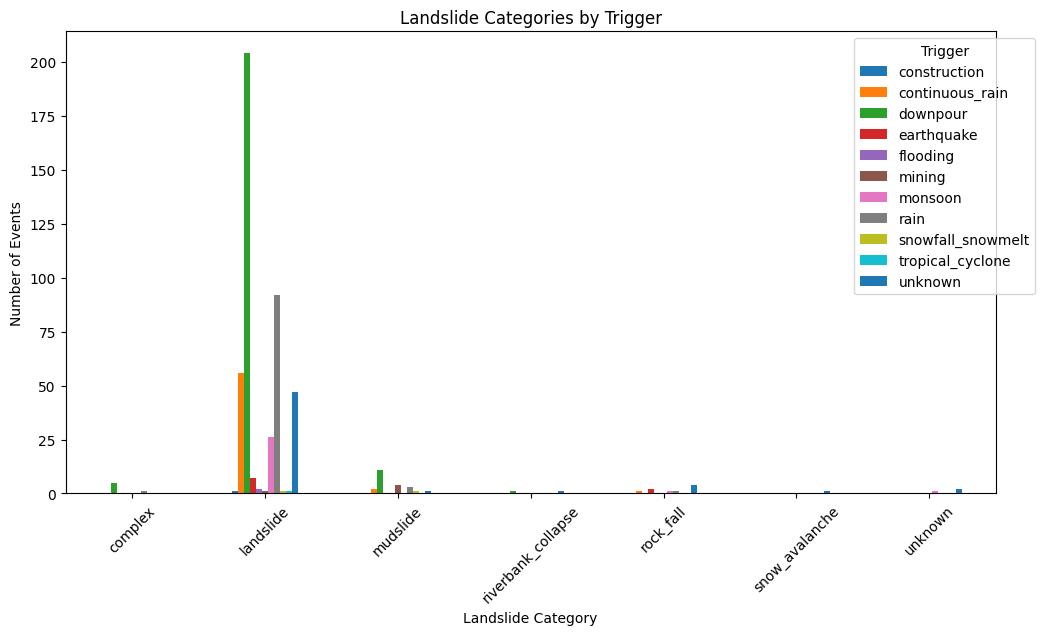

In [38]:
# Plot the relationship between category and trigger

plt.figure(figsize=(12, 6))

cross_tab.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Landslide Categories by Trigger")
plt.xlabel("Landslide Category")
plt.ylabel("Number of Events")

plt.xticks(rotation=45)
plt.legend(title="Trigger", bbox_to_anchor=(1.05, 1))

plt.show()

In [40]:
# Part 3: Identify numerical features available for Machine Learning

# Display all numerical columns in the dataset
print("Numerical columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

Numerical columns:
['event_id', 'event_time', 'fatality_count', 'injury_count', 'event_import_id', 'admin_division_population', 'gazeteer_distance', 'longitude', 'latitude']


In [41]:
# Display the data types of all columns
print("Column data types:")
display(df.dtypes)

Column data types:


,0
source_name,object
source_link,object
event_id,int64
event_date,object
event_time,float64
event_title,object
event_description,object
location_description,object
location_accuracy,object
landslide_category,object


In [42]:
# Display a few numerical columns to understand their values
display(df.select_dtypes(include=np.number).head())

,event_id,event_time,fatality_count,injury_count,event_import_id,admin_division_population,gazeteer_distance,longitude,latitude
0,684,NaN,11.0,NaN,684.0,0.0,41.02145,107.4500,32.5625
1,956,NaN,0.0,NaN,956.0,36619.0,0.60342,-122.6630,45.4200
2,973,NaN,10.0,NaN,973.0,14708.0,0.85548,-75.3587,-11.1295
3,1067,NaN,1.0,NaN,1067.0,20908.0,0.75395,81.7080,28.8378
4,2603,NaN,0.0,NaN,2603.0,798634.0,2.02204,123.8978,10.3336


In [43]:
# Identify numerical features available in the dataset

numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(numerical_columns.tolist())

Numerical columns:
['event_id', 'event_time', 'fatality_count', 'injury_count', 'event_import_id', 'admin_division_population', 'gazeteer_distance', 'longitude', 'latitude']


In [45]:
# Display the numerical variables for the first few records

display(df[numerical_columns].head())

,event_id,event_time,fatality_count,injury_count,event_import_id,admin_division_population,gazeteer_distance,longitude,latitude
0,684,NaN,11.0,NaN,684.0,0.0,41.02145,107.4500,32.5625
1,956,NaN,0.0,NaN,956.0,36619.0,0.60342,-122.6630,45.4200
2,973,NaN,10.0,NaN,973.0,14708.0,0.85548,-75.3587,-11.1295
3,1067,NaN,1.0,NaN,1067.0,20908.0,0.75395,81.7080,28.8378
4,2603,NaN,0.0,NaN,2603.0,798634.0,2.02204,123.8978,10.3336


In [46]:
# Check the possible target variables

print("Landslide categories:")
print(df["landslide_category"].value_counts())

print("\nLandslide sizes:")
print(df["landslide_size"].value_counts())

print("\nLandslide triggers:")
print(df["landslide_trigger"].value_counts())

Landslide categories:
landslide_category
landslide              7648
mudslide               2100
rock_fall               671
complex                 232
debris_flow             194
other                    68
unknown                  38
riverbank_collapse       37
snow_avalanche           15
translational_slide       9
lahar                     7
earth_flow                7
creep                     5
topple                    1
Name: count, dtype: int64

Landslide sizes:
landslide_size
medium          6551
small           2767
unknown          851
large            750
very_large       102
catastrophic       3
Name: count, dtype: int64

Landslide triggers:
landslide_trigger
downpour                   4680
rain                       2592
unknown                    1691
continuous_rain             748
tropical_cyclone            561
snowfall_snowmelt           135
monsoon                     129
mining                       93
earthquake                   89
construction                 

In [47]:
# Unit 2: Prepare numerical data for Machine Learning

# Select useful numerical variables
ml_data = df[
    [
        "fatality_count",
        "injury_count",
        "admin_division_population",
        "gazeteer_distance",
        "longitude",
        "latitude"
    ]
].copy()

# Display the selected variables
display(ml_data.head())

# Check missing values
print("Missing values:")
display(ml_data.isnull().sum())

,fatality_count,injury_count,admin_division_population,gazeteer_distance,longitude,latitude
0,11.0,NaN,0.0,41.02145,107.4500,32.5625
1,0.0,NaN,36619.0,0.60342,-122.6630,45.4200
2,10.0,NaN,14708.0,0.85548,-75.3587,-11.1295
3,1.0,NaN,20908.0,0.75395,81.7080,28.8378
4,0.0,NaN,798634.0,2.02204,123.8978,10.3336


Missing values:


,0
fatality_count,1385
injury_count,5674
admin_division_population,1562
gazeteer_distance,1562
longitude,0
latitude,0


In [48]:
# Remove records with missing values in the selected variables

ml_data = ml_data.dropna()

print("Shape after removing missing values:")
print(ml_data.shape)

# Check that no missing values remain
display(ml_data.isnull().sum())

Shape after removing missing values:
(3876, 6)


,0
fatality_count,0
injury_count,0
admin_division_population,0
gazeteer_distance,0
longitude,0
latitude,0


In [49]:
# Display statistical summary of the cleaned ML dataset

display(ml_data.describe())

,fatality_count,injury_count,admin_division_population,gazeteer_distance,longitude,latitude
count,3876.000000,3876.000000,3.876000e+03,3876.000000,3876.000000,3876.000000
mean,2.268576,0.839009,9.559228e+04,12.908560,-22.206292,31.038720
std,35.751463,8.343490,5.721199e+05,16.304652,100.653700,18.117732
min,0.000000,0.000000,0.000000e+00,0.000030,-159.495400,-46.774800
25%,0.000000,0.000000,1.795000e+03,2.730420,-122.085050,21.368325
50%,0.000000,0.000000,4.935000e+03,7.360150,-79.550850,36.996800
75%,0.000000,0.000000,2.290075e+04,17.287405,83.676150,44.551275
max,2100.000000,374.000000,1.269184e+07,199.448930,178.535800,65.979400


In [50]:
# Unit 2: Bayesian Linear Regression

# Select input features
X = ml_data[
    [
        "injury_count",
        "admin_division_population",
        "gazeteer_distance",
        "longitude",
        "latitude"
    ]
]

# Select target variable
y = ml_data["fatality_count"]

print("Features (X):")
display(X.head())

print("\nTarget (y):")
display(y.head())

Features (X):


,injury_count,admin_division_population,gazeteer_distance,longitude,latitude
11,0.0,12883.0,0.87786,-122.817800,45.864700
14,1.0,6721.0,5.53530,124.041900,12.565500
56,28.0,153635.0,2.58880,-44.322498,-23.013744
57,0.0,3742.0,3.64565,-123.158700,45.233500
121,1.0,8818.0,0.33828,12.396600,47.446000



Target (y):


,fatality_count
11,0.0
14,0.0
56,22.0
57,0.0
121,1.0


In [51]:
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 3100
Testing samples: 776


In [52]:
# Import Bayesian Linear Regression
from sklearn.linear_model import BayesianRidge

# Create the Bayesian Ridge regression model
model = BayesianRidge()

# Train the model
model.fit(X_train, y_train)

print("Bayesian Linear Regression model trained successfully.")

Bayesian Linear Regression model trained successfully.


In [53]:
# Predict fatality counts for the test data

y_pred = model.predict(X_test)

# Display actual and predicted values
results = pd.DataFrame({
    "Actual Fatalities": y_test.values,
    "Predicted Fatalities": y_pred
})

display(results.head(10))

,Actual Fatalities,Predicted Fatalities
0,0.0,0.010469
1,0.0,2.753634
2,0.0,4.418003
3,1.0,6.047627
4,0.0,0.506697
5,0.0,0.770925
6,0.0,-0.964769
7,0.0,-1.392102
8,0.0,0.087295
9,0.0,0.956517


In [54]:
# Evaluate the Bayesian Linear Regression model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Bayesian Linear Regression Performance")
print("--------------------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²   :", r2)

Bayesian Linear Regression Performance
--------------------------------------
MAE : 3.2749071754677592
RMSE: 12.926667383305453
R²   : 0.13416220042091986


In [55]:
# Unit 2: Classification
# Target: Whether a landslide event resulted in a fatality

classification_data = df[
    [
        "injury_count",
        "admin_division_population",
        "gazeteer_distance",
        "longitude",
        "latitude",
        "fatality_count"
    ]
].copy()

# Remove rows with missing values
classification_data = classification_data.dropna()

# Create binary target
# 0 = No fatality
# 1 = One or more fatalities
classification_data["fatality"] = (
    classification_data["fatality_count"] > 0
).astype(int)

# Remove the original fatality_count because it directly determines the target
classification_data = classification_data.drop(columns=["fatality_count"])

display(classification_data.head())

,injury_count,admin_division_population,gazeteer_distance,longitude,latitude,fatality
11,0.0,12883.0,0.87786,-122.817800,45.864700,0
14,1.0,6721.0,5.53530,124.041900,12.565500,0
56,28.0,153635.0,2.58880,-44.322498,-23.013744,1
57,0.0,3742.0,3.64565,-123.158700,45.233500,0
121,1.0,8818.0,0.33828,12.396600,47.446000,1


In [56]:
# Check how many events belong to each class

print("Classification target distribution:")
print(classification_data["fatality"].value_counts())

Classification target distribution:
fatality
0    3125
1     751
Name: count, dtype: int64


In [57]:
# Define input features (X)
X = classification_data.drop(columns=["fatality"])

# Define target variable (y)
y = classification_data["fatality"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("0 = No fatality")
print("1 = Fatality")

Features:
['injury_count', 'admin_division_population', 'gazeteer_distance', 'longitude', 'latitude']

Target:
0 = No fatality
1 = Fatality


In [58]:
# Split the data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 3100
Testing samples: 776


In [59]:
classification_data["fatality"].value_counts()

,count
fatality,
0,3125
1,751


In [60]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Learn scaling from training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling to test data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [61]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create the classification model
logistic_model = LogisticRegression(
    max_iter=1000
)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [62]:
# Predict the classes of the test data
y_pred_logistic = logistic_model.predict(X_test_scaled)

print("First 20 predictions:")
print(y_pred_logistic[:20])

First 20 predictions:
[0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0]


In [63]:
# Import classification evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Calculate performance
accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic, zero_division=0)
recall = recall_score(y_test, y_pred_logistic, zero_division=0)
f1 = f1_score(y_test, y_pred_logistic, zero_division=0)

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic, zero_division=0))

Logistic Regression Performance
--------------------------------
Accuracy : 0.8208762886597938
Precision: 0.6037735849056604
Recall   : 0.21333333333333335
F1 Score : 0.31527093596059114

Confusion Matrix:
[[605  21]
 [118  32]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.97      0.90       626
           1       0.60      0.21      0.32       150

    accuracy                           0.82       776
   macro avg       0.72      0.59      0.61       776
weighted avg       0.79      0.82      0.78       776



In [64]:
# Train an SVM classification model

from sklearn.svm import SVC

# Create the SVM model
svm_model = SVC()

# Train the model using the training data
svm_model.fit(X_train_scaled, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


In [65]:
# Evaluate the SVM classification model

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Make predictions on the test data
y_pred_svm = svm_model.predict(X_test_scaled)

# Calculate performance metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, zero_division=0)
recall_svm = recall_score(y_test, y_pred_svm, zero_division=0)
f1_svm = f1_score(y_test, y_pred_svm, zero_division=0)

print("SVM Performance")
print("----------------")
print("Accuracy :", accuracy_svm)
print("Precision:", precision_svm)
print("Recall   :", recall_svm)
print("F1 Score :", f1_svm)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

SVM Performance
----------------
Accuracy : 0.8402061855670103
Precision: 0.7708333333333334
Recall   : 0.24666666666666667
F1 Score : 0.37373737373737376

Confusion Matrix:
[[615  11]
 [113  37]]


In [66]:
# Install and import PyMC for Bayesian Logistic Regression

!pip install -q pymc

import pymc as pm
import numpy as np

print("PyMC is ready.")

PyMC is ready.


In [67]:
# Build the Bayesian Logistic Regression model

with pm.Model() as bayesian_logistic_model:

    # Prior distributions for the model parameters
    beta = pm.Normal("beta", mu=0, sigma=1, shape=X_train_scaled.shape[1])
    intercept = pm.Normal("intercept", mu=0, sigma=1)

    # Calculate probability using logistic function
    logits = intercept + pm.math.dot(X_train_scaled, beta)
    probability = pm.math.sigmoid(logits)

    # Observed data
    outcome = pm.Bernoulli(
        "outcome",
        p=probability,
        observed=y_train
    )

print("Bayesian Logistic Regression model created.")

Bayesian Logistic Regression model created.


In [69]:
# Train the Bayesian Logistic Regression model

with bayesian_logistic_model:
    trace = pm.sample(
        1000,
        tune=500,
        chains=2,
        target_accept=0.9,
        random_seed=42
    )

print("Bayesian Logistic Regression trained successfully.")

 Progress                     Draw   Divergences   Step size   Grad evals   Speed            Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━━   1500   0             0.458       7            187.78 draws/s   0:00:07   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━   1500   0             0.567       7            107.27 draws/s   0:00:13   0:00:00

Bayesian Logistic Regression trained successfully.


In [70]:
# Make predictions using the Bayesian Logistic Regression model

# Get posterior samples of the model parameters
beta_samples = trace.posterior["beta"].values
intercept_samples = trace.posterior["intercept"].values

# Combine chains and samples
beta_samples = beta_samples.reshape(-1, beta_samples.shape[-1])
intercept_samples = intercept_samples.reshape(-1)

# Calculate probabilities for the test data
logits = (
    X_test_scaled @ beta_samples.T
    + intercept_samples
)

probabilities = 1 / (1 + np.exp(-logits))

# Average probability across all posterior samples
y_prob_bayesian = probabilities.mean(axis=1)

# Convert probabilities into 0 or 1
y_pred_bayesian = (y_prob_bayesian >= 0.5).astype(int)

print("Bayesian Logistic Regression predictions created.")

Bayesian Logistic Regression predictions created.


In [71]:
# Evaluate Bayesian Logistic Regression

accuracy_bayesian = accuracy_score(y_test, y_pred_bayesian)
precision_bayesian = precision_score(y_test, y_pred_bayesian, zero_division=0)
recall_bayesian = recall_score(y_test, y_pred_bayesian, zero_division=0)
f1_bayesian = f1_score(y_test, y_pred_bayesian, zero_division=0)

print("Bayesian Logistic Regression Performance")
print("----------------------------------------")
print("Accuracy :", accuracy_bayesian)
print("Precision:", precision_bayesian)
print("Recall   :", recall_bayesian)
print("F1 Score :", f1_bayesian)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_bayesian))

Bayesian Logistic Regression Performance
----------------------------------------
Accuracy : 0.8221649484536082
Precision: 0.6111111111111112
Recall   : 0.22
F1 Score : 0.3235294117647059

Confusion Matrix:
[[605  21]
 [117  33]]


In [72]:
# Compare the performance of the classification models

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Bayesian Logistic Regression"
    ],
    "Accuracy": [
        0.8208762886597938,
        accuracy_svm,
        accuracy_bayesian
    ],
    "Precision": [
        0.6037735849056604,
        precision_svm,
        precision_bayesian
    ],
    "Recall": [
        0.21333333333333335,
        recall_svm,
        recall_bayesian
    ],
    "F1 Score": [
        0.31527093596059114,
        f1_svm,
        f1_bayesian
    ]
})

display(comparison)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.820876,0.603774,0.213333,0.315271
1,SVM,0.840206,0.770833,0.246667,0.373737
2,Bayesian Logistic Regression,0.822165,0.611111,0.220000,0.323529


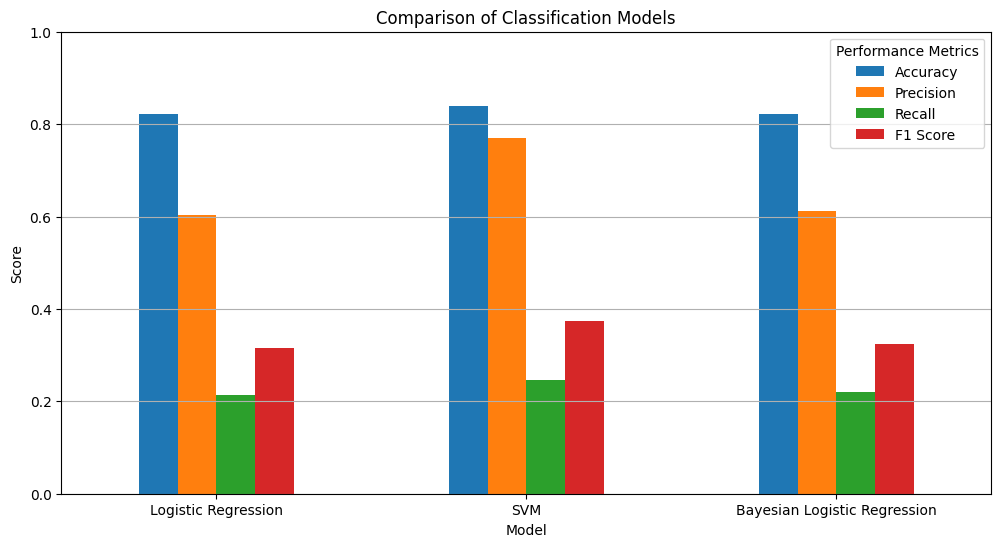

In [73]:
# Compare classification model performance visually

comparison.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of Classification Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Performance Metrics")
plt.grid(axis="y")
plt.show()